In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score, roc_auc_score, precision_recall_curve, roc_curve, make_scorer


# Avoid warnings
import warnings
warnings.filterwarnings('ignore')

### Problem definition, questions to be answered - Data background and contents - Univariate analysis - Bivariate analysis - Key meaningful observations for each of the plot

In [3]:
#Load and Preprocess the Data
file_path = 'Loan_Modelling.csv'  # Path to the dataset
data = pd.read_csv(file_path)

# Display initial sample and data info
print("Initial Data Sample:")
print(data.head(), "\n")
print("Data Info:")
print(data.info(), "\n")
# Check for missing values
print("Missing Values:")
print(data.isnull().sum(), "\n")

Initial Data Sample:
   ID  Age  Experience  Income  ZIPCode  Family  CCAvg  Education  Mortgage  \
0   1   25           1      49    91107       4    1.6          1         0   
1   2   45          19      34    90089       3    1.5          1         0   
2   3   39          15      11    94720       1    1.0          1         0   
3   4   35           9     100    94112       1    2.7          2         0   
4   5   35           8      45    91330       4    1.0          2         0   

   Personal_Loan  Securities_Account  CD_Account  Online  CreditCard  
0              0                   1           0       0           0  
1              0                   1           0       0           0  
2              0                   0           0       0           0  
3              0                   0           0       0           0  
4              0                   0           0       0           1   

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0

In [4]:
#Statistical summary of the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


## Univariate Analysis

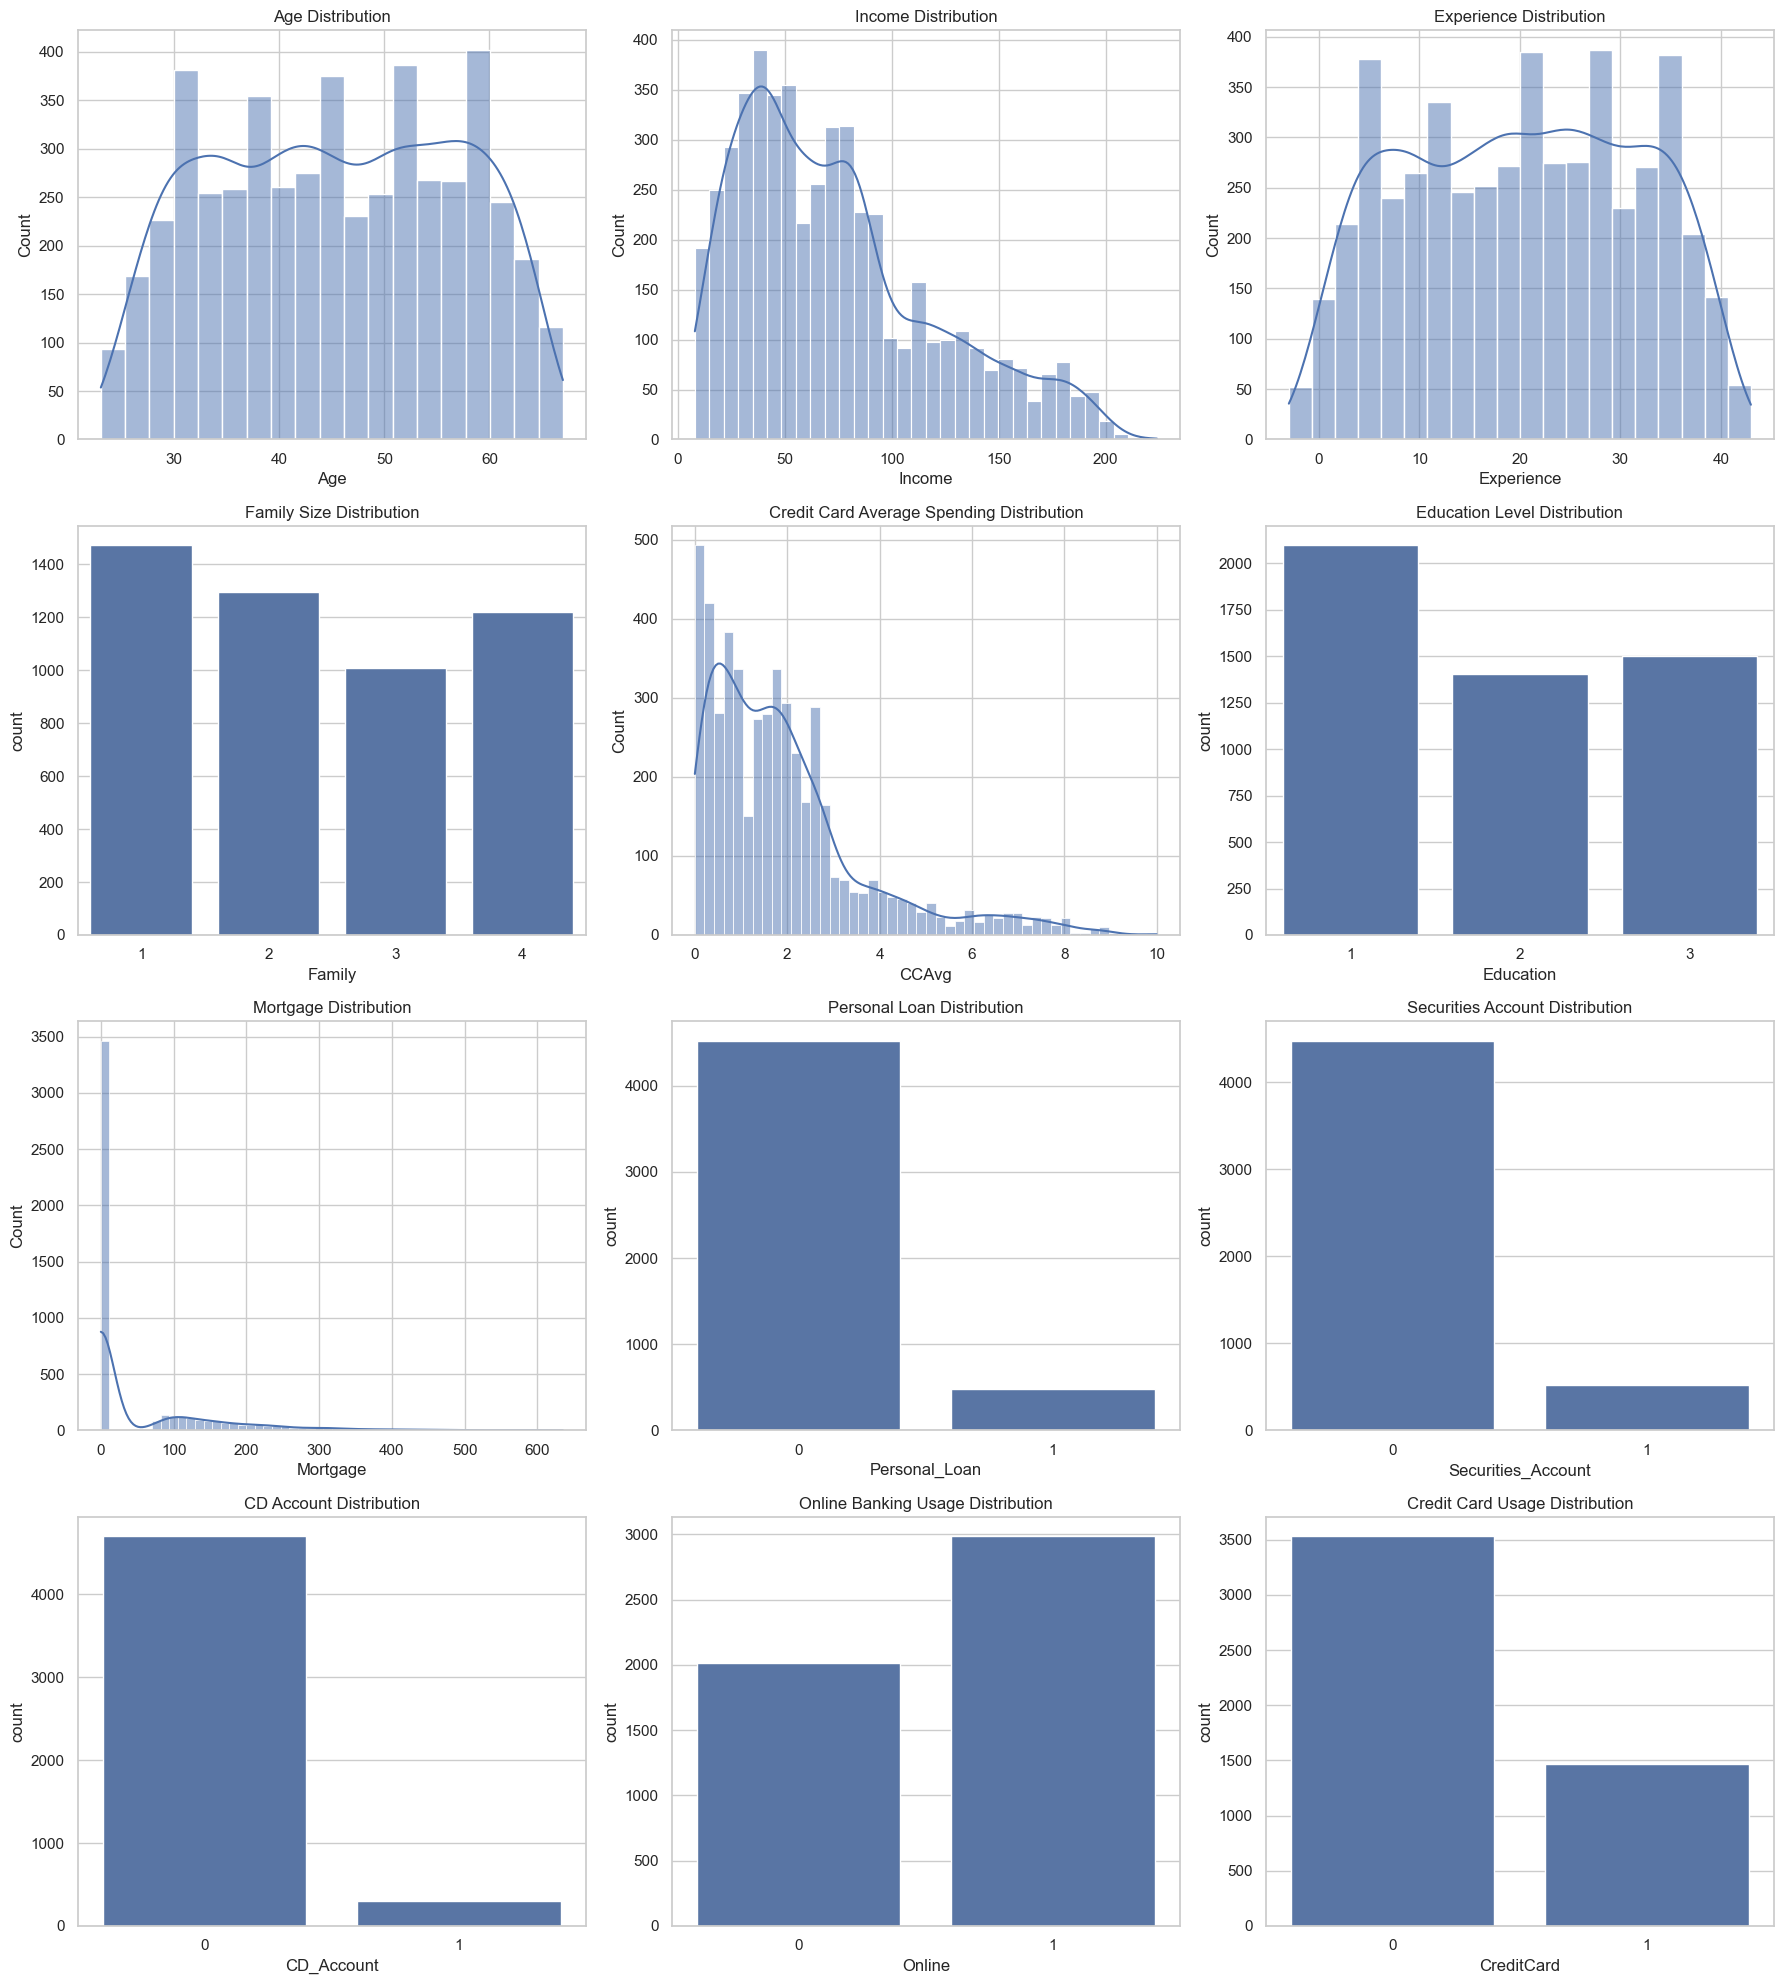

In [6]:
# Set the style for the plots
sns.set(style="whitegrid")

# Create subplots for univariate analysis
fig, axes = plt.subplots(4, 3, figsize=(18, 20))

# Age Distribution
sns.histplot(data['Age'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution')

# Income Distribution
sns.histplot(data['Income'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Income Distribution')

# Experience Distribution
sns.histplot(data['Experience'], kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Experience Distribution')

# Family Size Distribution
sns.countplot(x='Family', data=data, ax=axes[1, 0])
axes[1, 0].set_title('Family Size Distribution')

# Credit Card Average Spending Distribution
sns.histplot(data['CCAvg'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Credit Card Average Spending Distribution')

# Education Level Distribution
sns.countplot(x='Education', data=data, ax=axes[1, 2])
axes[1, 2].set_title('Education Level Distribution')

# Mortgage Distribution
sns.histplot(data['Mortgage'], kde=True, ax=axes[2, 0])
axes[2, 0].set_title('Mortgage Distribution')

# Personal Loan Distribution
sns.countplot(x='Personal_Loan', data=data, ax=axes[2, 1])
axes[2, 1].set_title('Personal Loan Distribution')

# Securities Account Distribution
sns.countplot(x='Securities_Account', data=data, ax=axes[2, 2])
axes[2, 2].set_title('Securities Account Distribution')

# CD Account Distribution
sns.countplot(x='CD_Account', data=data, ax=axes[3, 0])
axes[3, 0].set_title('CD Account Distribution')

# Online Banking Usage Distribution
sns.countplot(x='Online', data=data, ax=axes[3, 1])
axes[3, 1].set_title('Online Banking Usage Distribution')

# Credit Card Usage Distribution
sns.countplot(x='CreditCard', data=data, ax=axes[3, 2])
axes[3, 2].set_title('Credit Card Usage Distribution')

# Adjust layout
plt.tight_layout()
plt.show()



## Bivariate Analysis

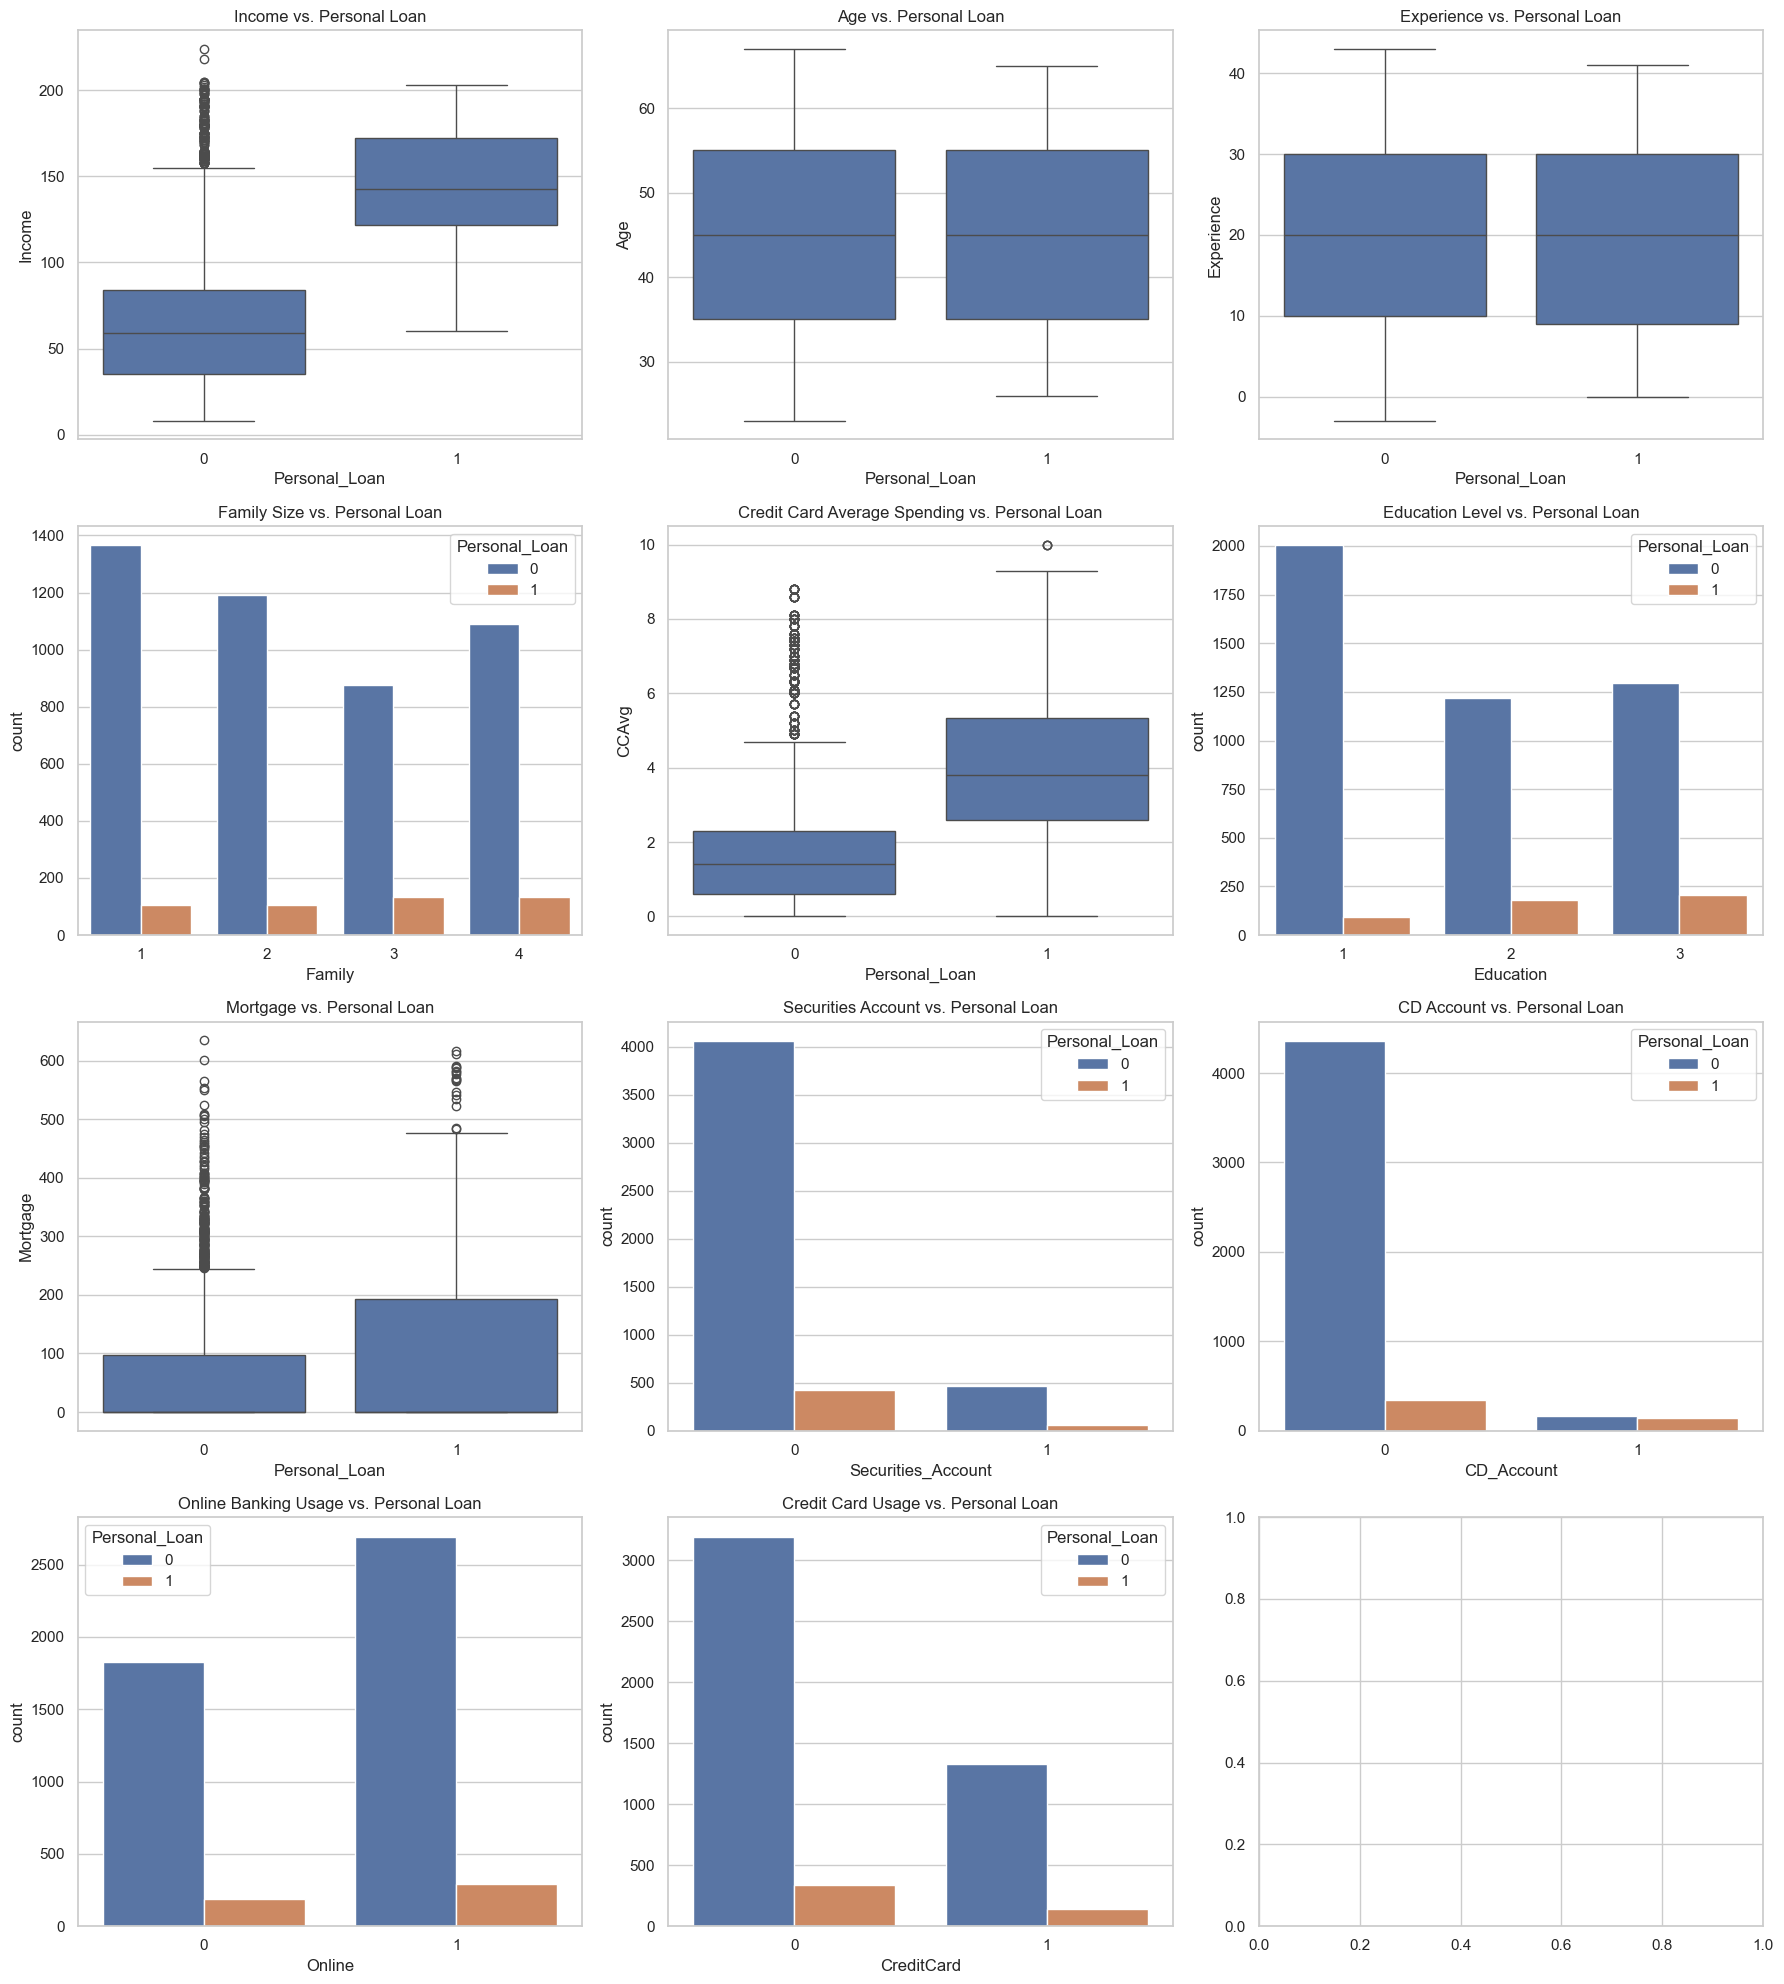

In [8]:
# Create subplots for bivariate analysis
fig, axes = plt.subplots(4, 3, figsize=(18, 20))

# Income vs. Personal Loan
sns.boxplot(x='Personal_Loan', y='Income', data=data, ax=axes[0, 0])
axes[0, 0].set_title('Income vs. Personal Loan')

# Age vs. Personal Loan
sns.boxplot(x='Personal_Loan', y='Age', data=data, ax=axes[0, 1])
axes[0, 1].set_title('Age vs. Personal Loan')

# Experience vs. Personal Loan
sns.boxplot(x='Personal_Loan', y='Experience', data=data, ax=axes[0, 2])
axes[0, 2].set_title('Experience vs. Personal Loan')

# Family Size vs. Personal Loan
sns.countplot(x='Family', hue='Personal_Loan', data=data, ax=axes[1, 0])
axes[1, 0].set_title('Family Size vs. Personal Loan')

# Credit Card Average Spending vs. Personal Loan
sns.boxplot(x='Personal_Loan', y='CCAvg', data=data, ax=axes[1, 1])
axes[1, 1].set_title('Credit Card Average Spending vs. Personal Loan')

# Education Level vs. Personal Loan
sns.countplot(x='Education', hue='Personal_Loan', data=data, ax=axes[1, 2])
axes[1, 2].set_title('Education Level vs. Personal Loan')

# Mortgage vs. Personal Loan
sns.boxplot(x='Personal_Loan', y='Mortgage', data=data, ax=axes[2, 0])
axes[2, 0].set_title('Mortgage vs. Personal Loan')

# Securities Account vs. Personal Loan
sns.countplot(x='Securities_Account', hue='Personal_Loan', data=data, ax=axes[2, 1])
axes[2, 1].set_title('Securities Account vs. Personal Loan')

# CD Account vs. Personal Loan
sns.countplot(x='CD_Account', hue='Personal_Loan', data=data, ax=axes[2, 2])
axes[2, 2].set_title('CD Account vs. Personal Loan')

# Online Banking Usage vs. Personal Loan
sns.countplot(x='Online', hue='Personal_Loan', data=data, ax=axes[3, 0])
axes[3, 0].set_title('Online Banking Usage vs. Personal Loan')

# Credit Card Usage vs. Personal Loan
sns.countplot(x='CreditCard', hue='Personal_Loan', data=data, ax=axes[3, 1])
axes[3, 1].set_title('Credit Card Usage vs. Personal Loan')

# Adjust layout
plt.tight_layout()
plt.show()

#### Observations

- Income vs. Personal Loan: Higher income is associated with a higher likelihood of having a personal loan.
- Age vs. Personal Loan: Age does not significantly impact the likelihood of having a personal loan.
- Experience vs. Personal Loan: Experience does not significantly impact the likelihood of having a personal loan.
- Family Size vs. Personal Loan: Family size does not significantly impact the likelihood of having a personal loan.
- Credit Card Average Spending vs. Personal Loan: Higher average credit card spending is associated with a higher likelihood of having a personal loan.
- Education Level vs. Personal Loan: Higher education levels are associated with a higher likelihood of having a personal loan.
- Mortgage vs. Personal Loan: Higher mortgage values are associated with a higher likelihood of having a personal loan.
- Securities Account vs. Personal Loan: Having a securities account is associated with a higher likelihood of having a personal loan.
- CD Account vs. Personal Loan: Having a CD account is associated with a higher likelihood of having a personal loan.
- Online Banking Usage vs. Personal Loan: Online banking usage does not significantly impact the likelihood of having a personal loan.
- Credit Card Usage vs. Personal Loan: Using a credit card issued by the bank is associated with a higher likelihood of having a personal loan.

### Prepare the data for analysis: - Missing Value Treatment (if needed) - Outlier Detection (treat, if needed) - Feature Engineering - Data preparation for modelling 

In [11]:
# Experience can't be negative, looks like data issue. Convert them to positive
data['Experience'] = data['Experience'].apply(abs)

# Discribe rows and info about the dataset
print(data.describe())
print(data.info())

                ID          Age   Experience       Income       ZIPCode  \
count  5000.000000  5000.000000  5000.000000  5000.000000   5000.000000   
mean   2500.500000    45.338400    20.134600    73.774200  93169.257000   
std    1443.520003    11.463166    11.415189    46.033729   1759.455086   
min       1.000000    23.000000     0.000000     8.000000  90005.000000   
25%    1250.750000    35.000000    10.000000    39.000000  91911.000000   
50%    2500.500000    45.000000    20.000000    64.000000  93437.000000   
75%    3750.250000    55.000000    30.000000    98.000000  94608.000000   
max    5000.000000    67.000000    43.000000   224.000000  96651.000000   

            Family        CCAvg    Education     Mortgage  Personal_Loan  \
count  5000.000000  5000.000000  5000.000000  5000.000000    5000.000000   
mean      2.396400     1.937938     1.881000    56.498800       0.096000   
std       1.147663     1.747659     0.839869   101.713802       0.294621   
min       1.000000  

In [12]:
# 1. Missing Value Treatment
# Check for missing values
missing_values = data.isnull().sum()
print("Missing Values:\n", missing_values)

# If there are missing values, we can treat them
# For numerical columns, we can fill missing values with the median
for column in data.select_dtypes(include=[np.number]).columns:
    if data[column].isnull().any():
        median_value = data[column].median()
        data[column].fillna(median_value, inplace=True)

# Verify that there are no missing values left
print("Missing Values After Treatment:\n", data.isnull().sum())

Missing Values:
 ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64
Missing Values After Treatment:
 ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64


In [13]:
# 2. Outlier Detection and Treatment
# Using the IQR method to detect outliers
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

# Detect outliers for numerical columns
outliers = {}
for column in data.select_dtypes(include=[np.number]).columns:
    if(column != 'Personal_Loan'): # Exclude Personal_Loan
        outliers[column] = detect_outliers_iqr(data, column)

# Print outliers detected
for column, outlier_data in outliers.items():
    print(f"Outliers in {column}:\n", outlier_data)

# Treat outliers by capping them at the upper and lower bounds
for column in data.select_dtypes(include=[np.number]).columns:
    if(column != 'Personal_Loan'): # Exclude Personal_Loan
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = int(round(Q1 - 1.5 * IQR))
        upper_bound = int(round(Q3 + 1.5 * IQR))
        data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
        data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])

Outliers in ID:
 Empty DataFrame
Columns: [ID, Age, Experience, Income, ZIPCode, Family, CCAvg, Education, Mortgage, Personal_Loan, Securities_Account, CD_Account, Online, CreditCard]
Index: []
Outliers in Age:
 Empty DataFrame
Columns: [ID, Age, Experience, Income, ZIPCode, Family, CCAvg, Education, Mortgage, Personal_Loan, Securities_Account, CD_Account, Online, CreditCard]
Index: []
Outliers in Experience:
 Empty DataFrame
Columns: [ID, Age, Experience, Income, ZIPCode, Family, CCAvg, Education, Mortgage, Personal_Loan, Securities_Account, CD_Account, Online, CreditCard]
Index: []
Outliers in Income:
         ID  Age  Experience  Income  ZIPCode  Family  CCAvg  Education  \
18      19   46          21     193    91604       2   8.10          3   
47      48   37          12     194    91380       4   0.20          3   
53      54   50          26     190    90245       3   2.10          3   
59      60   31           5     188    91320       2   4.50          1   
303    304   49   

In [14]:
# 3. Feature Engineering
data['Income_to_Experience'] = data['Income'] / (data['Experience'] + 1)  # Adding 1 to avoid division by zero

# Example: Create a binary feature for high income
data['High_Income'] = np.where(data['Income'] > 100, 1, 0)  # Assuming income is in $000

In [15]:
# 4. Data Preparation for Modeling
# Convert categorical variables to dummy/indicator variables
data = pd.get_dummies(data, columns=['Education', 'Family', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard'], drop_first=True)

# Define features and target variable
X = data.drop(columns=['ID', 'Personal_Loan'])  # Features
y = data['Personal_Loan']  # Target variable

# Display the prepared data
print("Prepared Data for Modeling:\n", X.head())
print("Target Variable:\n", y.head())

Prepared Data for Modeling:
    Age  Experience  Income  ZIPCode  CCAvg  Mortgage  Income_to_Experience  \
0   25           1      49    91107    1.6         0               24.5000   
1   45          19      34    90089    1.5         0                1.7000   
2   39          15      11    94720    1.0         0                0.6875   
3   35           9     100    94112    2.7         0               10.0000   
4   35           8      45    91330    1.0         0                5.0000   

   High_Income  Education_2  Education_3  Family_2  Family_3  Family_4  \
0            0        False        False     False     False      True   
1            0        False        False     False      True     False   
2            0        False        False     False     False     False   
3            0         True        False     False     False     False   
4            0         True        False     False     False      True   

   Online_1  CreditCard_1  
0     False         False  
1

### Model building - Decision Tree - Define model evaluation criterion - Build the model and comment on the model performance. - Visualize the decision rules and important features

In [17]:
def confusion_matrix_custom(model, predictors, target):
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [18]:
def get_recall_score(model, predictors, target):
    prediction = model.predict(predictors)
    return recall_score(target, prediction)

In [19]:
# -----------------------------
# 1. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in test data =", X_test.shape[0])

print("Number of rows in train data =", y_train.shape[0])
print("Number of rows in test data =", y_test.shape[0])

Number of rows in train data = 3500
Number of rows in test data = 1500
Number of rows in train data = 3500
Number of rows in test data = 1500


In [21]:
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Percentage of classes in training set:
Personal_Loan
0    0.907714
1    0.092286
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.895333
1    0.104667
Name: proportion, dtype: float64


In [22]:
# -----------------------------
# 2. Baseline Decision Tree Model (No Pruning)
# -----------------------------
dt_model = DecisionTreeClassifier(random_state=1)
dt_model.fit(X_train, y_train)

# Predictions on test set
y_pred = dt_model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.3f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred), "\n")

Decision Tree Accuracy: 0.984

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.93      0.92      0.92       157

    accuracy                           0.98      1500
   macro avg       0.96      0.95      0.96      1500
weighted avg       0.98      0.98      0.98      1500
 



Recall Score: 1.0


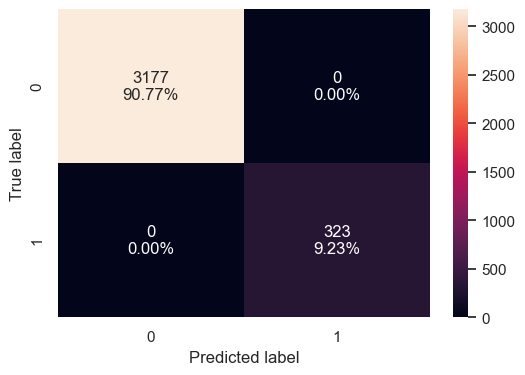

In [23]:
confusion_matrix_custom(dt_model, X_train, y_train)
decision_tree_perf_train = get_recall_score(dt_model, X_train, y_train)
print("Recall Score:", decision_tree_perf_train)

Recall Score: 0.9171974522292994


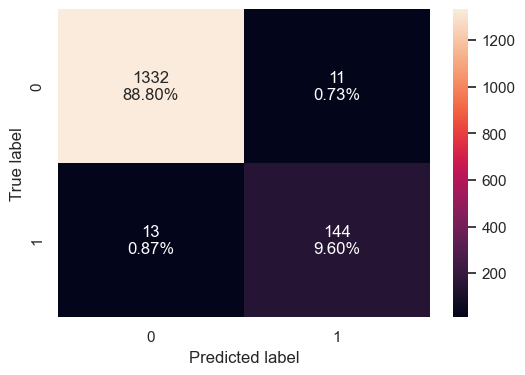

In [24]:
confusion_matrix_custom(dt_model, X_test, y_test)
decision_tree_perf_test = get_recall_score(dt_model, X_test, y_test)
print("Recall Score:", decision_tree_perf_test)

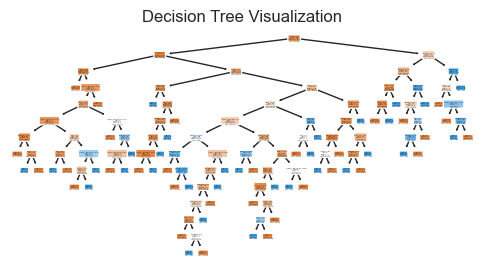

Decision Tree Rules:
|--- Income <= 113.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Income_to_Experience <= 22.50
|   |   |   |   |--- Family_4 <= 0.50
|   |   |   |   |   |--- Income_to_Experience <= 6.47
|   |   |   |   |   |   |--- Education_2 <= 0.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Education_2 >  0.50
|   |   |   |   |   |   |   |--- CCAvg <= 1.45
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- CCAvg >  1.45
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Income_to_Experience >  6.47
|   |   |   |   |   |   |--- Age <= 34.00
|   |   |   |   |   |   |   |--- Age <= 28.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- Age >  28.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Age >  34.00
|   |   |   |   |   |   |   |--- Income_to_Experience <= 8.16

In [25]:
# -----------------------------
# 3. Visualize the Decision Tree Rules
# -----------------------------
plt.figure(figsize=(6, 3))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['No Loan', 'Loan'],
          filled=True,
          rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

# Also print text representation of the decision rules
tree_rules = export_text(dt_model, feature_names=list(X.columns))
print("Decision Tree Rules:")
print(tree_rules)


Feature Importances:
Income                  0.301598
Education_2             0.217427
Education_3             0.151861
Family_3                0.081292
Family_4                0.079310
CCAvg                   0.059834
Income_to_Experience    0.031755
Mortgage                0.019190
ZIPCode                 0.016883
Experience              0.016620
Age                     0.015926
CreditCard_1            0.006029
Online_1                0.002274
High_Income             0.000000
Family_2                0.000000
dtype: float64


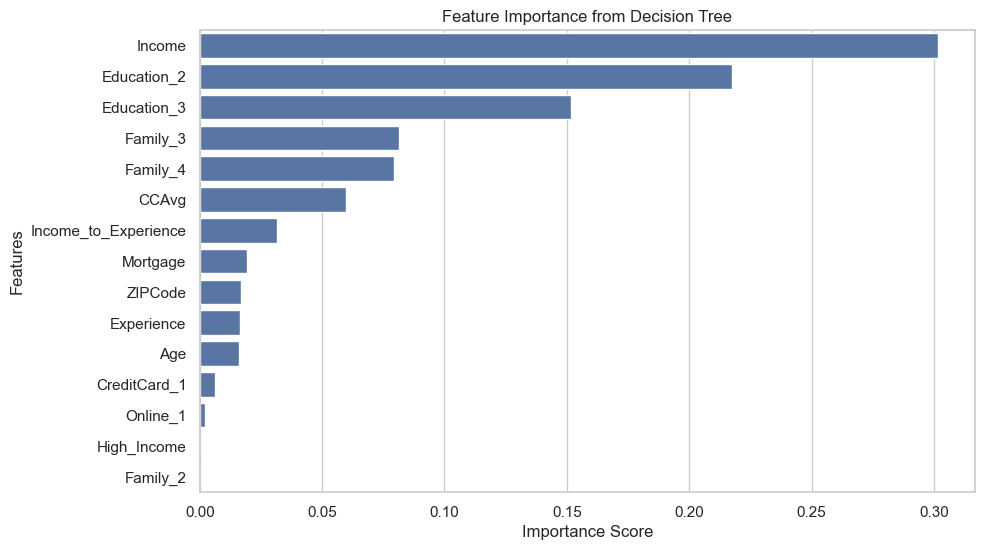

In [26]:
# -----------------------------
# 4. Identify and Visualize Important Features
# -----------------------------
# Get feature importances from the decision tree and sort them
feature_importances = pd.Series(dt_model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print("\nFeature Importances:")
print(feature_importances)

# Plot important features
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Feature Importance from Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

### Try and improve the model performance by pruning (Both Post and Pre pruning) - Check the performance of the pruned models, compare the performance of all the models built, and select the final model - Find the decision rules and check feature importance for the final model

In [28]:
# -----------------------------
# 1. Pre-Pruning: Control tree complexity via parameters
# -----------------------------
prepruned_model = DecisionTreeClassifier(random_state=42, max_depth=4, min_samples_split=50)
prepruned_model.fit(X_train, y_train)
y_pred_pre = prepruned_model.predict(X_test)
acc_pre = accuracy_score(y_test, y_pred_pre)

print("Pre-Pruned Model Accuracy: {:.3f}".format(acc_pre))
print("Pre-Pruned Model Classification Report:")
print(classification_report(y_test, y_pred_pre))
print("\n")


Pre-Pruned Model Accuracy: 0.970
Pre-Pruned Model Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1343
           1       1.00      0.71      0.83       157

    accuracy                           0.97      1500
   macro avg       0.98      0.86      0.91      1500
weighted avg       0.97      0.97      0.97      1500





In [29]:
acc = accuracy_score(y_test, y_pred_pre)  # to compute Accuracy
recall = recall_score(y_test, y_pred_pre)  # to compute Recall
precision = precision_score(y_test, y_pred_pre)  # to compute Precision
f1 = f1_score(y_test, y_pred_pre)  # to compute F1-score

df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,}, index=[0],)
df_perf

,Accuracy,Recall,Precision,F1
0,0.97,0.713376,1.0,0.832714


Number of candidate alpha values: 37
   Accuracy    Recall  Precision        F1
0  0.986667  0.923567   0.947712  0.935484


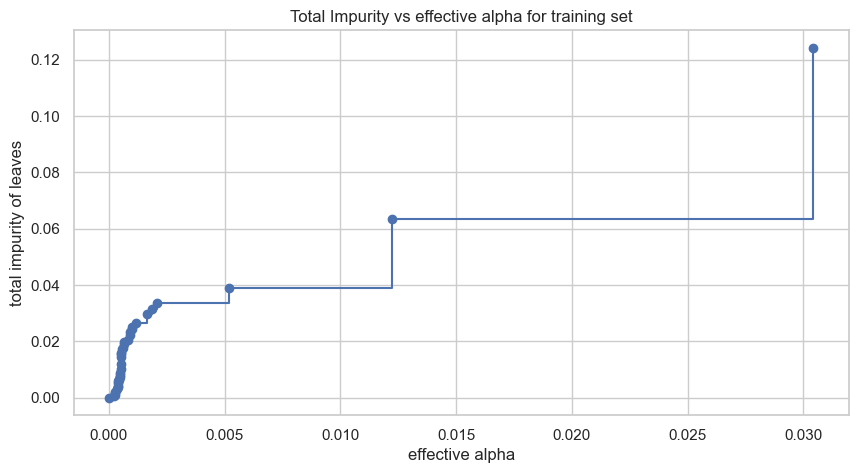

   Accuracy    Recall  Precision        F1
0     0.986  0.917197   0.947368  0.932039


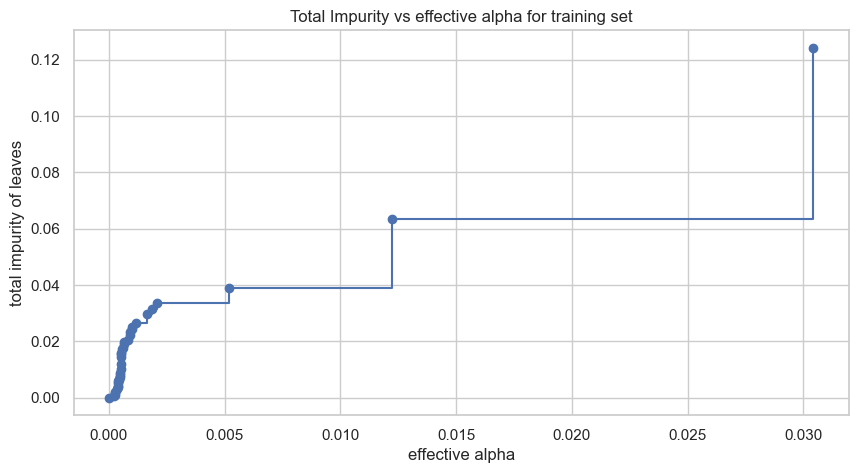

   Accuracy    Recall  Precision        F1
0  0.985333  0.917197   0.941176  0.929032


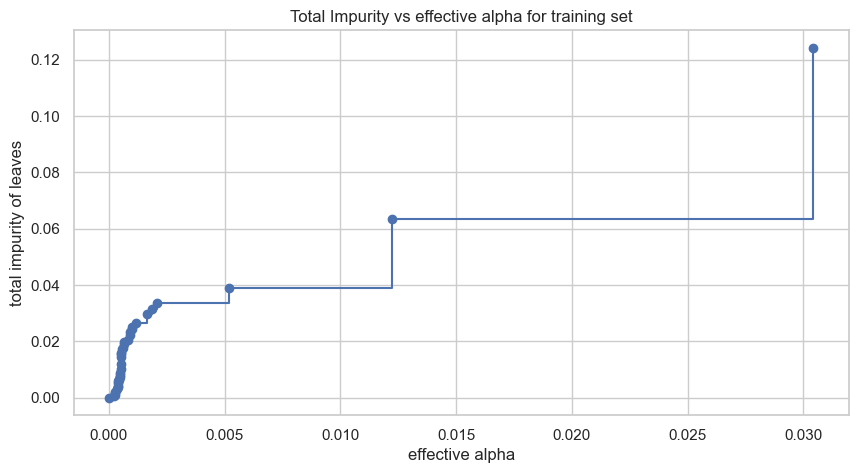

   Accuracy    Recall  Precision        F1
0  0.985333  0.917197   0.941176  0.929032


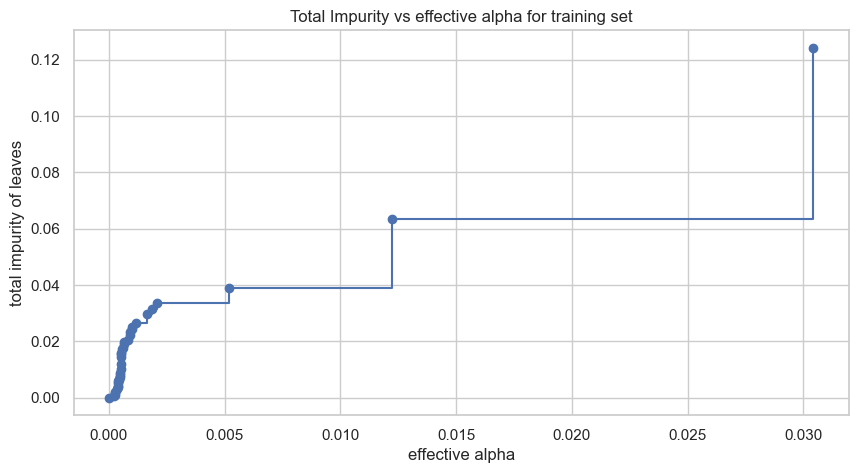

   Accuracy    Recall  Precision        F1
0  0.985333  0.917197   0.941176  0.929032


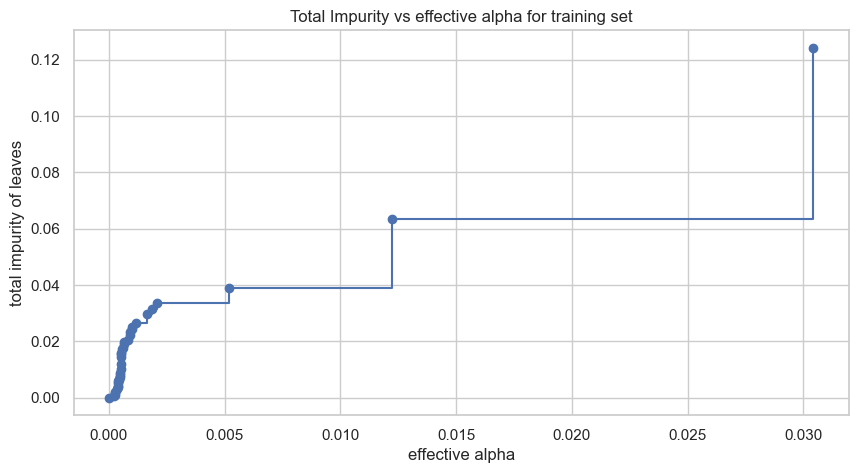

   Accuracy    Recall  Precision        F1
0  0.985333  0.917197   0.941176  0.929032


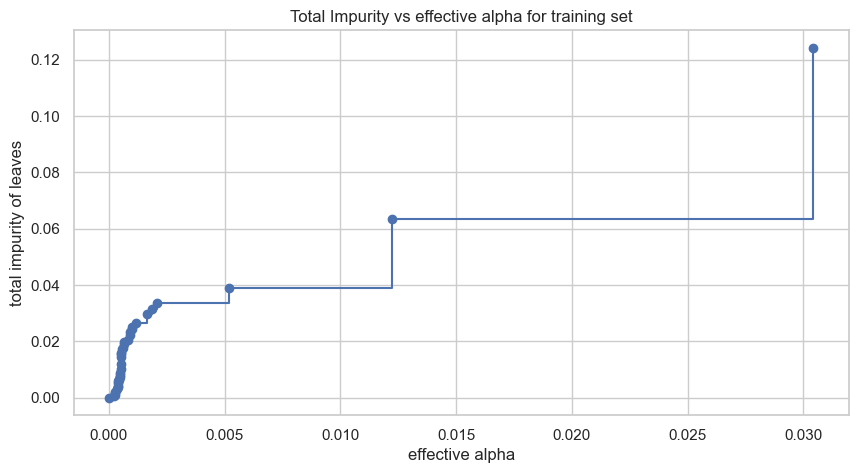

   Accuracy    Recall  Precision        F1
0     0.984  0.923567   0.923567  0.923567


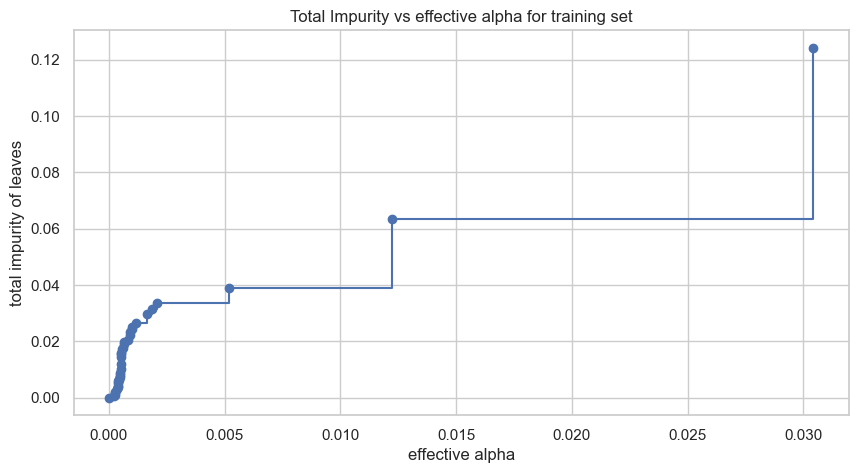

   Accuracy    Recall  Precision        F1
0     0.984  0.923567   0.923567  0.923567


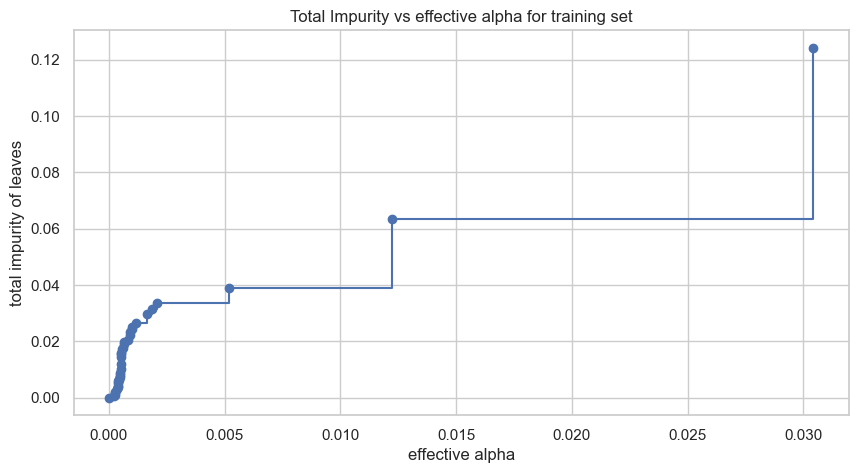

   Accuracy    Recall  Precision        F1
0     0.984  0.923567   0.923567  0.923567


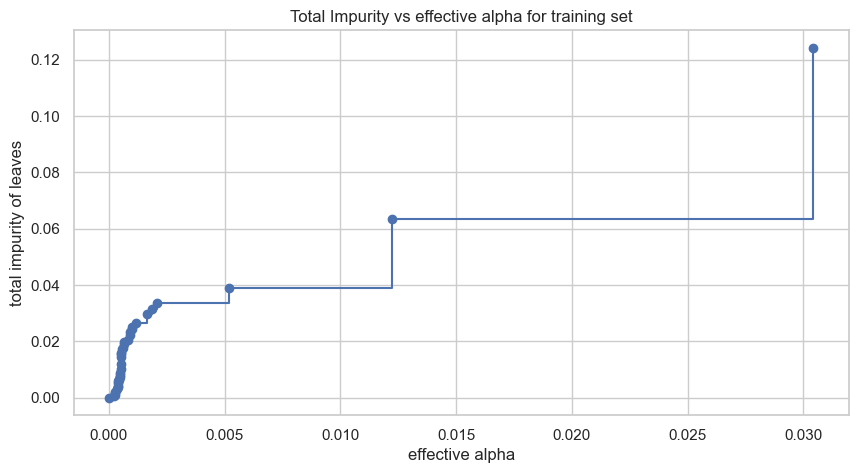

   Accuracy    Recall  Precision        F1
0  0.983333  0.923567   0.917722  0.920635


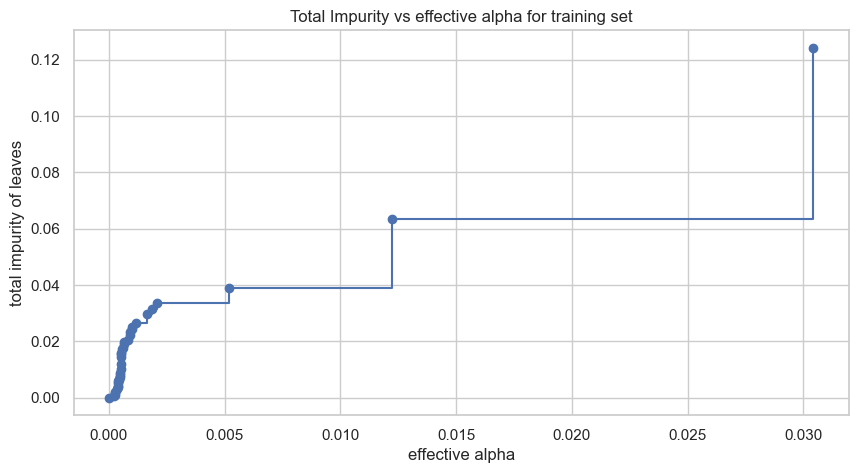

   Accuracy    Recall  Precision        F1
0  0.982667  0.923567    0.91195  0.917722


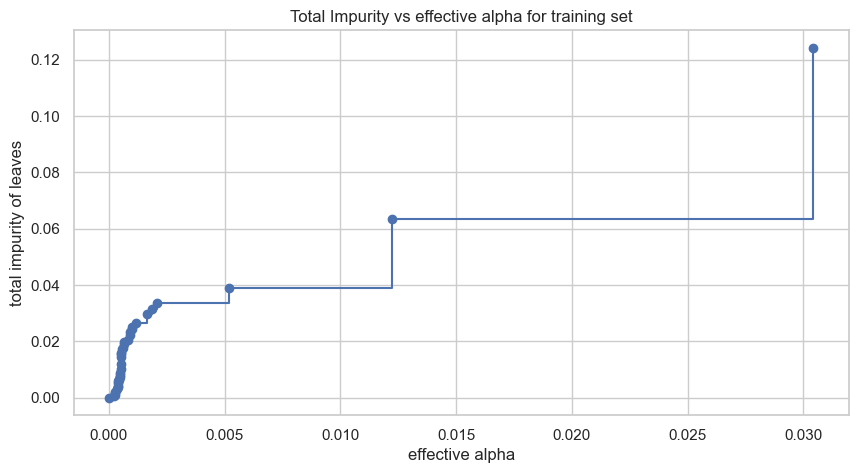

   Accuracy    Recall  Precision        F1
0  0.982667  0.923567    0.91195  0.917722


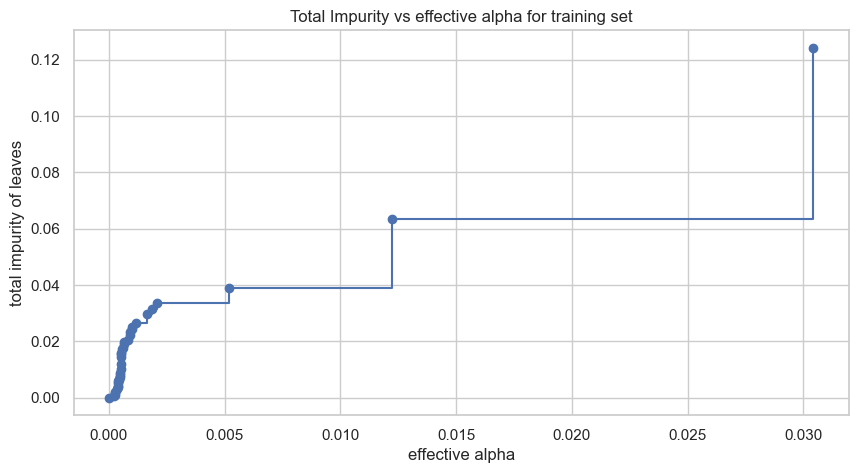

   Accuracy    Recall  Precision        F1
0  0.982667  0.923567    0.91195  0.917722


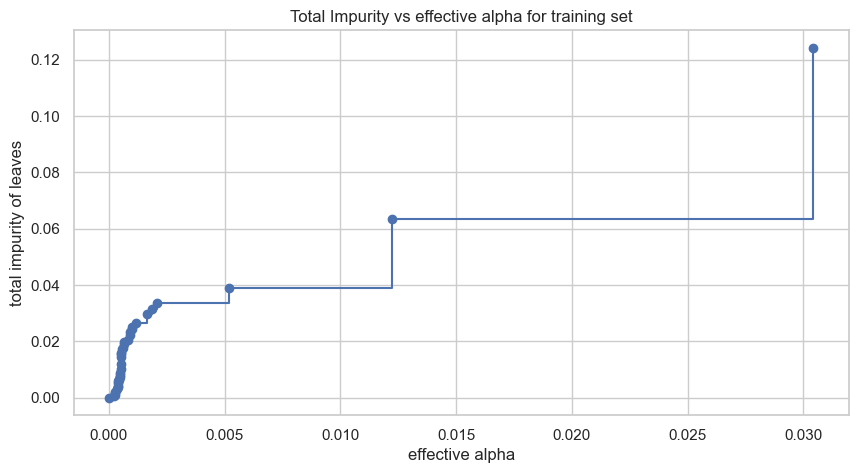

   Accuracy    Recall  Precision        F1
0  0.982667  0.923567    0.91195  0.917722


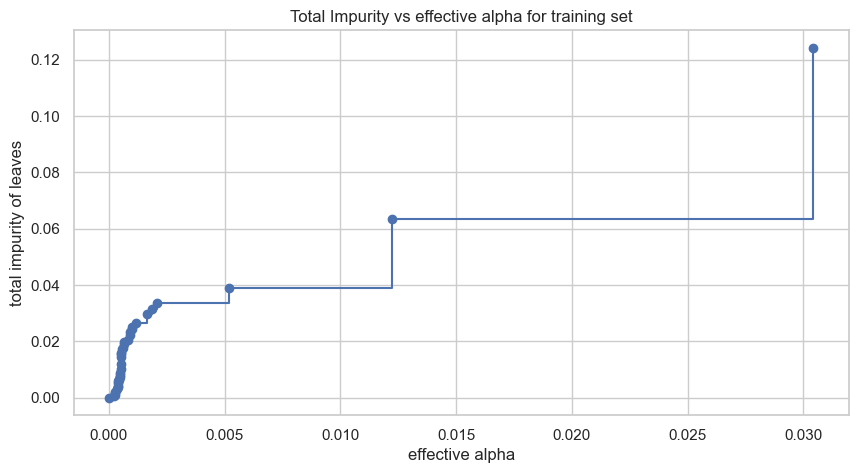

   Accuracy    Recall  Precision        F1
0  0.982667  0.923567    0.91195  0.917722


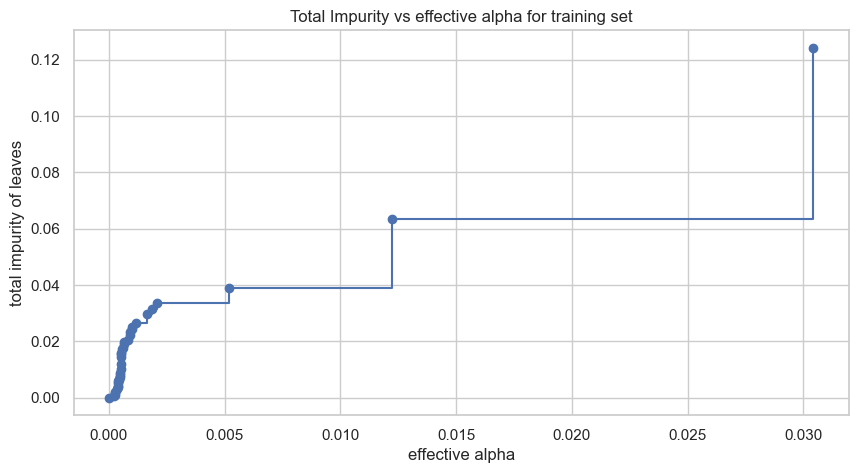

   Accuracy    Recall  Precision        F1
0  0.982667  0.923567    0.91195  0.917722


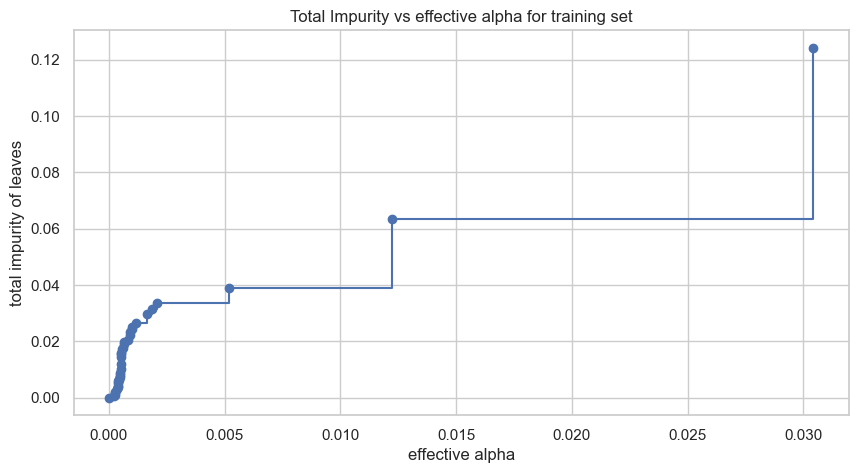

   Accuracy    Recall  Precision        F1
0     0.982  0.917197   0.911392  0.914286


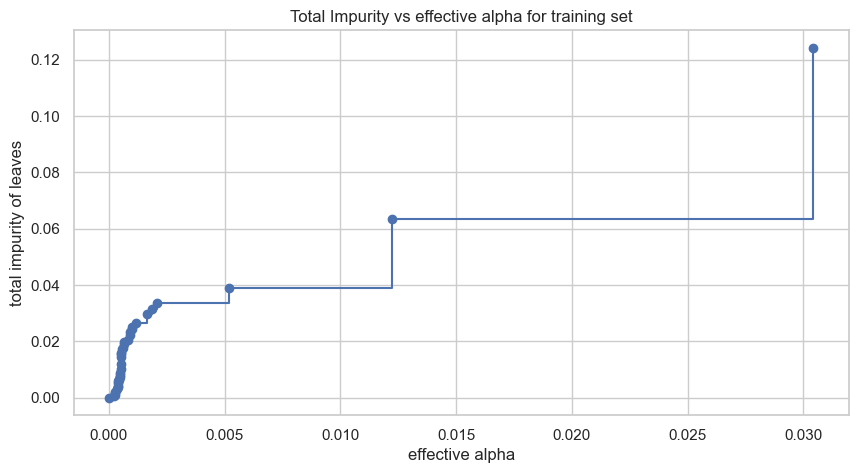

   Accuracy    Recall  Precision        F1
0     0.984  0.904459   0.940397  0.922078


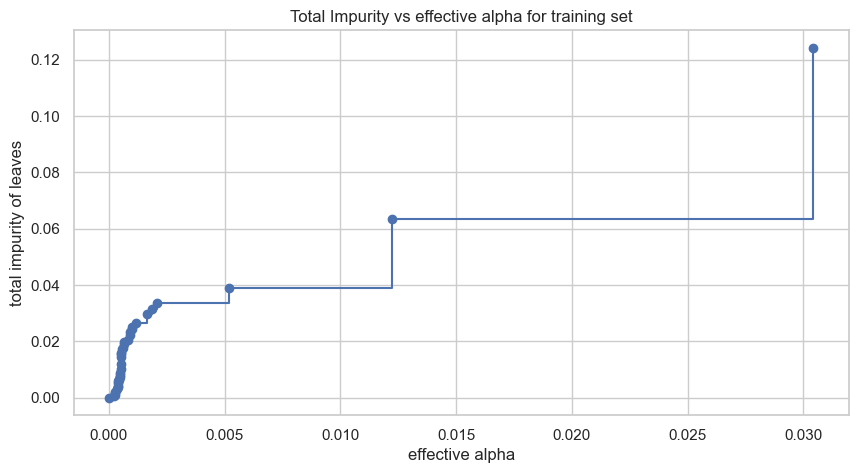

   Accuracy    Recall  Precision        F1
0  0.983333  0.898089       0.94  0.918567


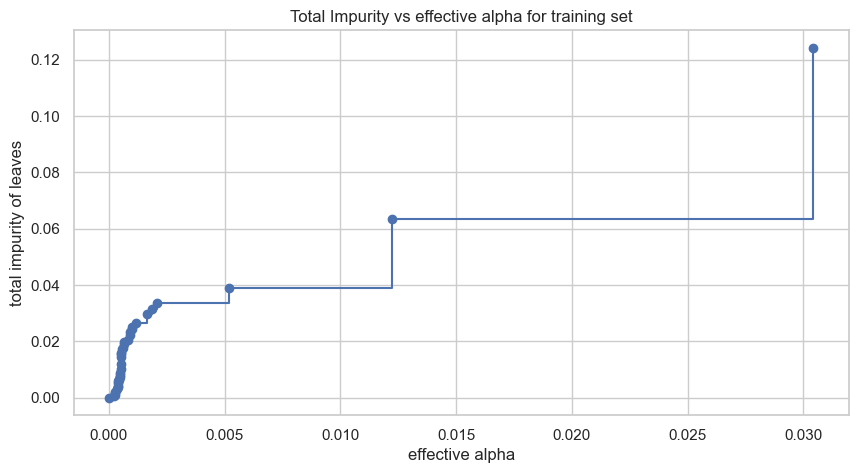

   Accuracy   Recall  Precision        F1
0  0.983333  0.89172   0.945946  0.918033


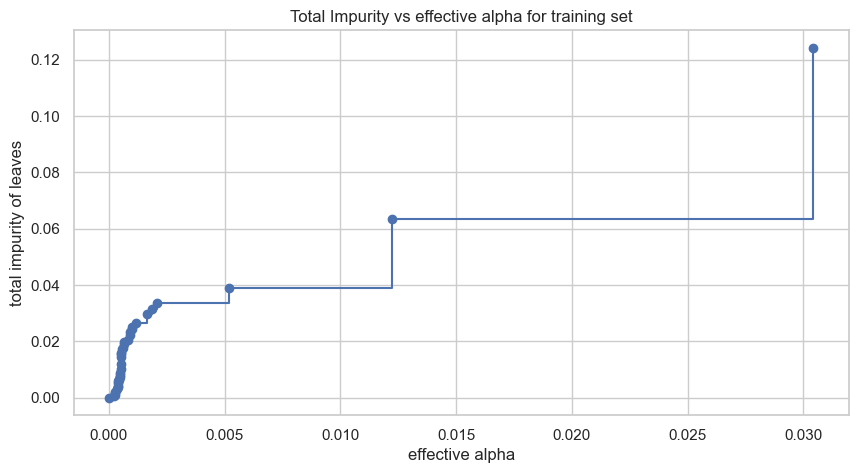

   Accuracy   Recall  Precision        F1
0  0.984667  0.89172   0.958904  0.924092


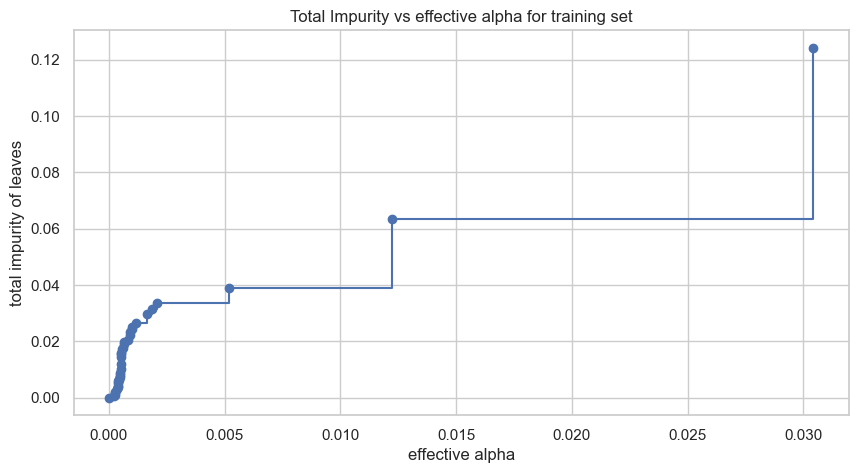

   Accuracy   Recall  Precision        F1
0  0.984667  0.88535   0.965278  0.923588


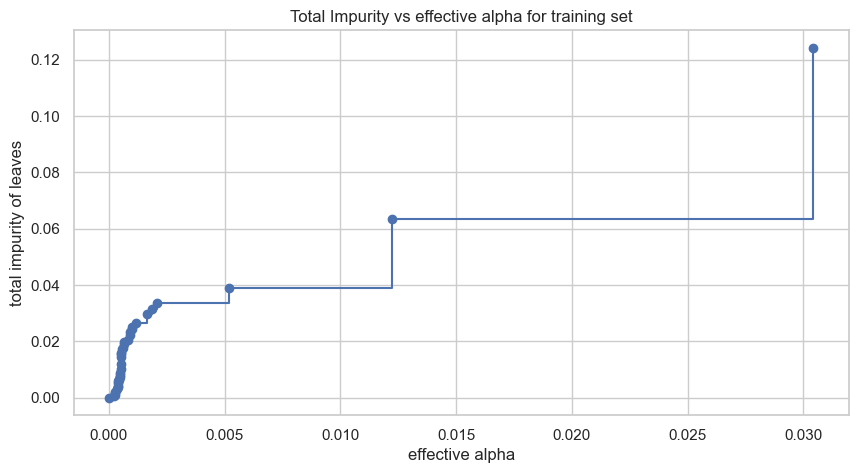

   Accuracy   Recall  Precision        F1
0  0.984667  0.88535   0.965278  0.923588


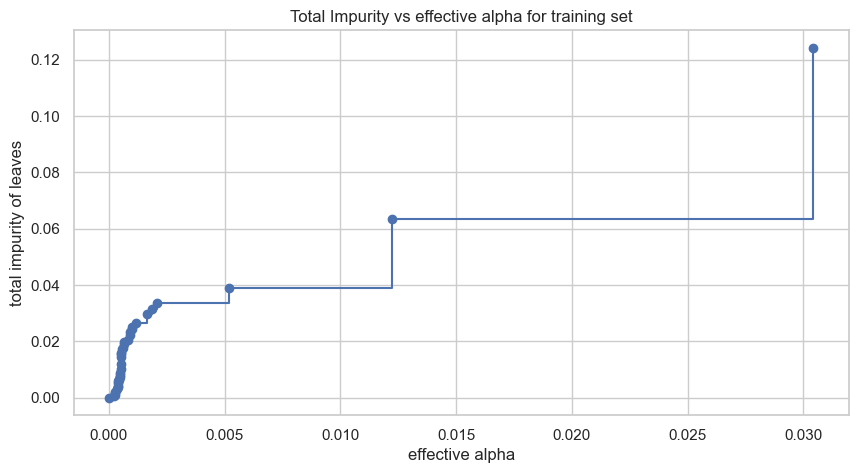

   Accuracy    Recall  Precision        F1
0  0.984667  0.878981   0.971831  0.923077


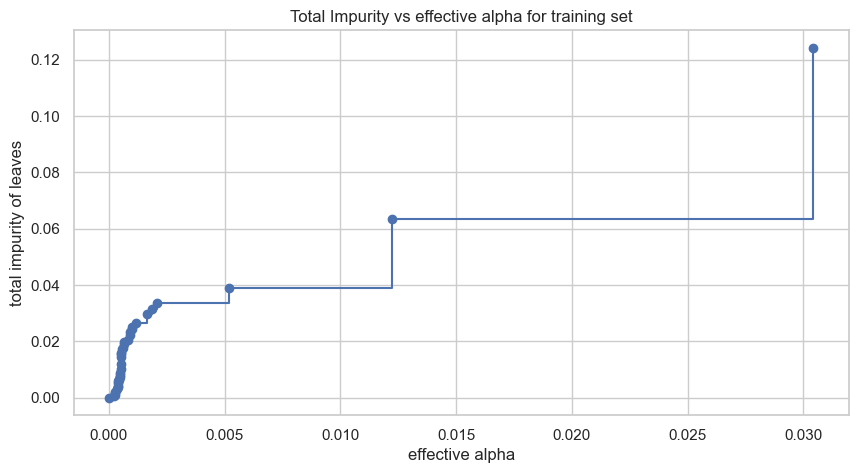

   Accuracy    Recall  Precision        F1
0  0.985333  0.872611   0.985612  0.925676


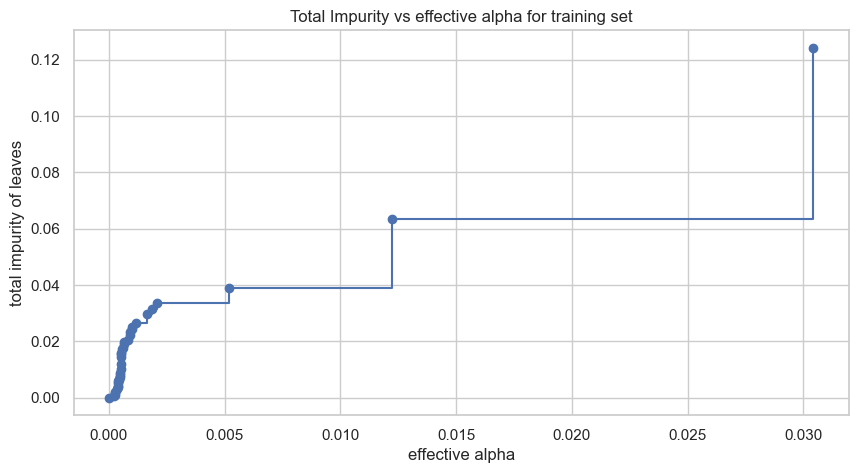

   Accuracy    Recall  Precision        F1
0     0.984  0.853503   0.992593  0.917808


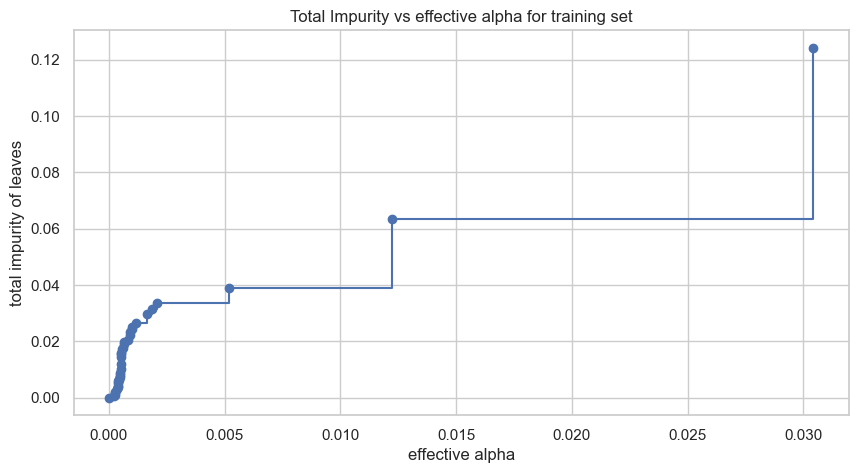

   Accuracy    Recall  Precision        F1
0  0.981333  0.828025   0.992366  0.902778


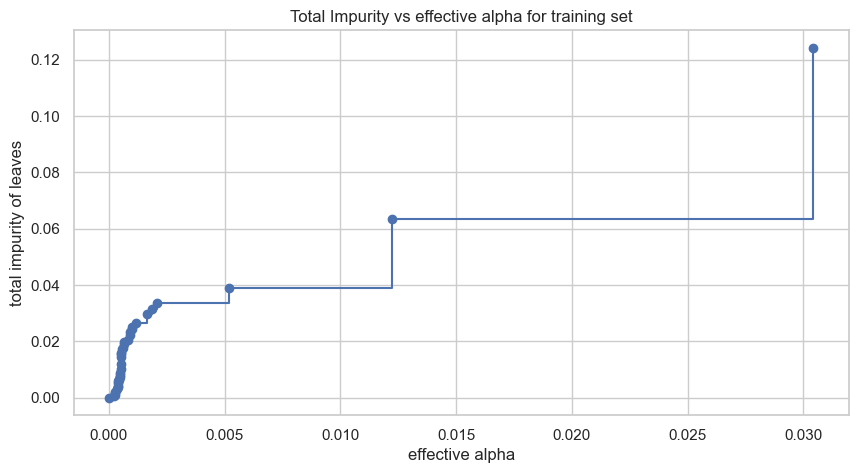

   Accuracy    Recall  Precision        F1
0  0.981333  0.828025   0.992366  0.902778


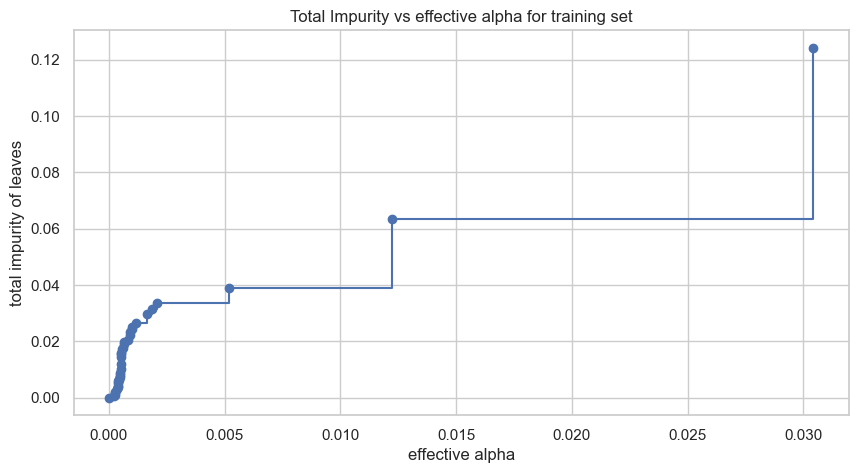

   Accuracy    Recall  Precision        F1
0  0.981333  0.828025   0.992366  0.902778


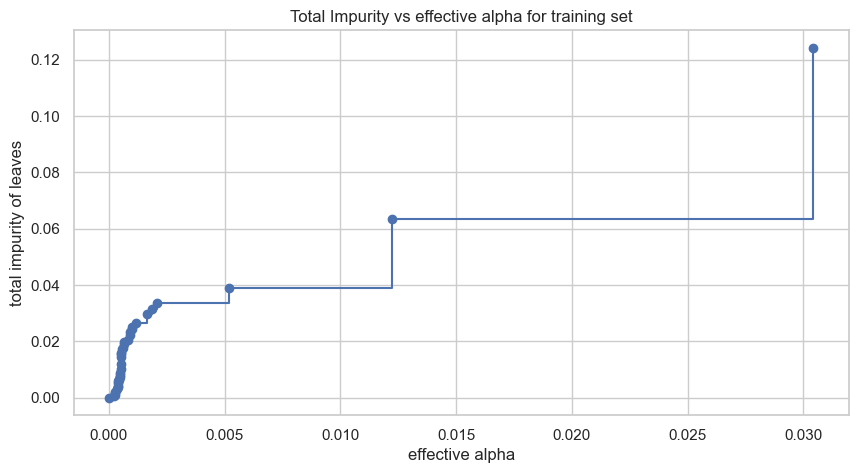

   Accuracy    Recall  Precision        F1
0  0.979333  0.802548        1.0  0.890459


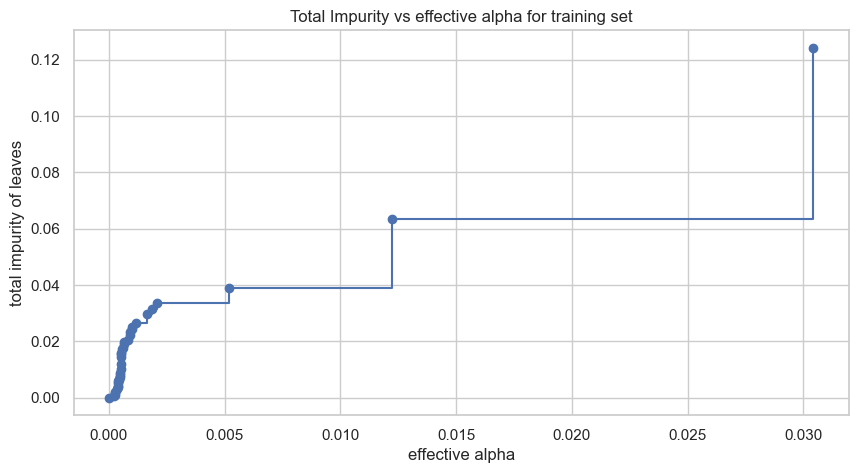

   Accuracy    Recall  Precision        F1
0  0.979333  0.802548        1.0  0.890459


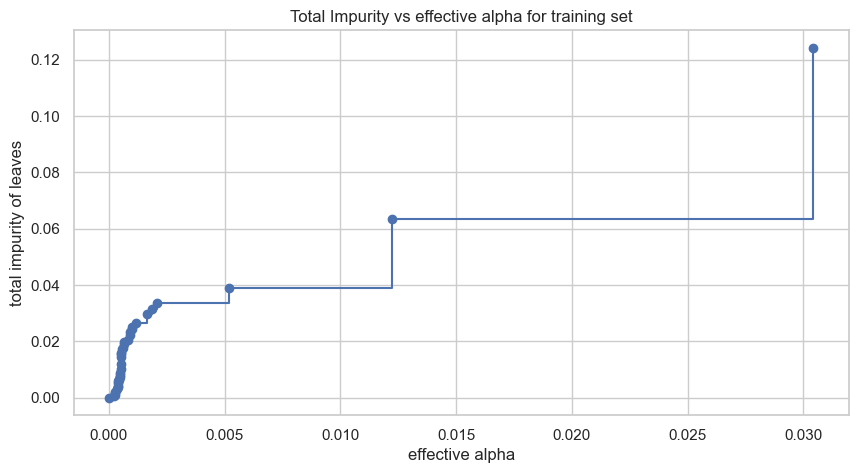

   Accuracy    Recall  Precision        F1
0  0.979333  0.815287   0.984615  0.891986


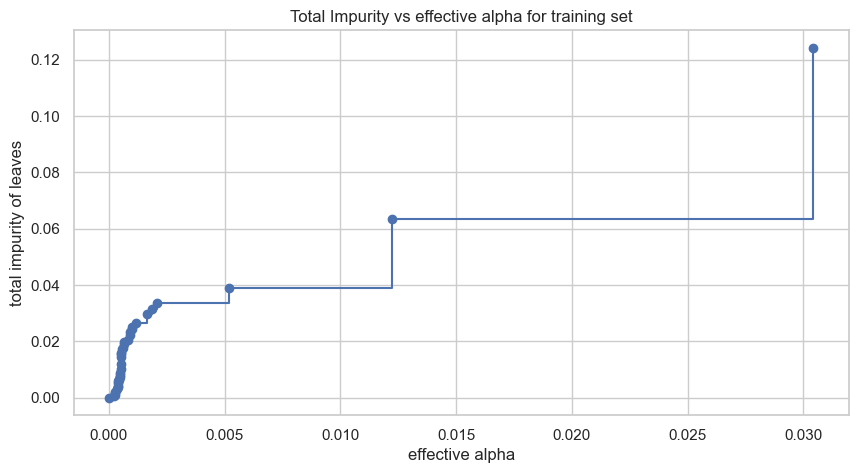

   Accuracy    Recall  Precision        F1
0  0.979333  0.828025   0.970149  0.893471


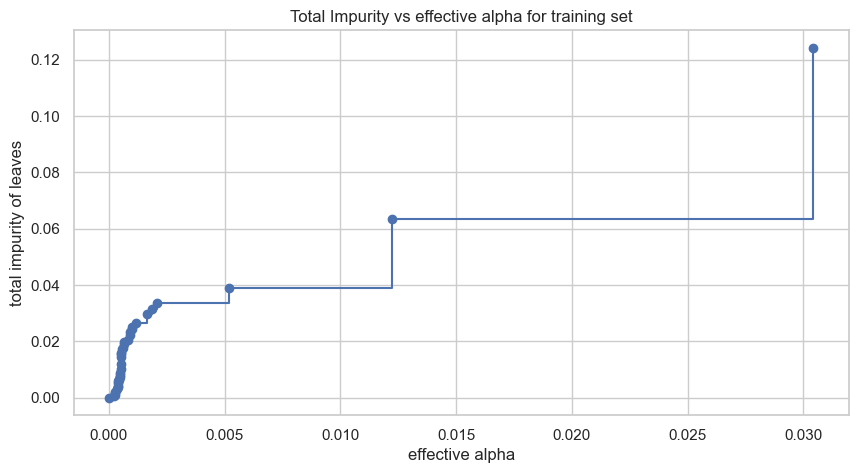

   Accuracy    Recall  Precision        F1
0  0.979333  0.828025   0.970149  0.893471


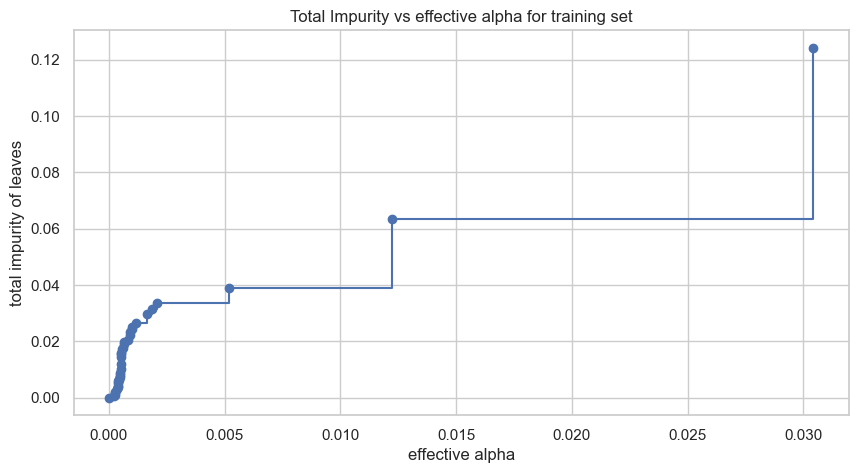

   Accuracy    Recall  Precision        F1
0  0.965333  0.694268   0.964602  0.807407


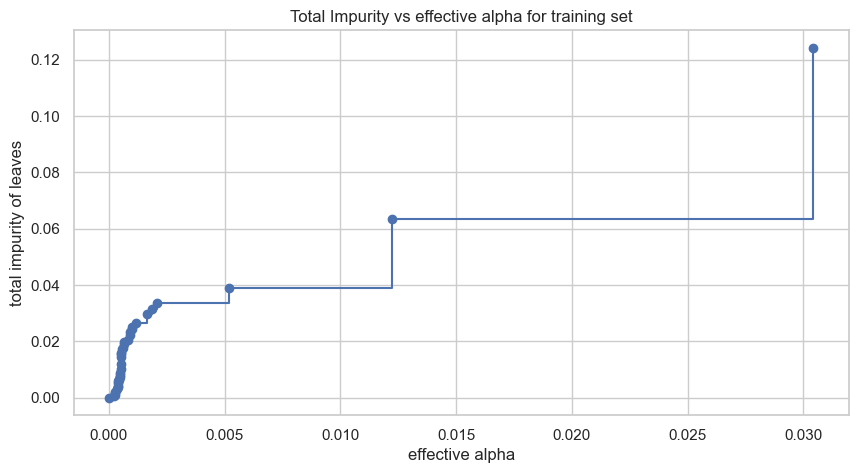

   Accuracy  Recall  Precision   F1
0  0.895333     0.0        0.0  0.0


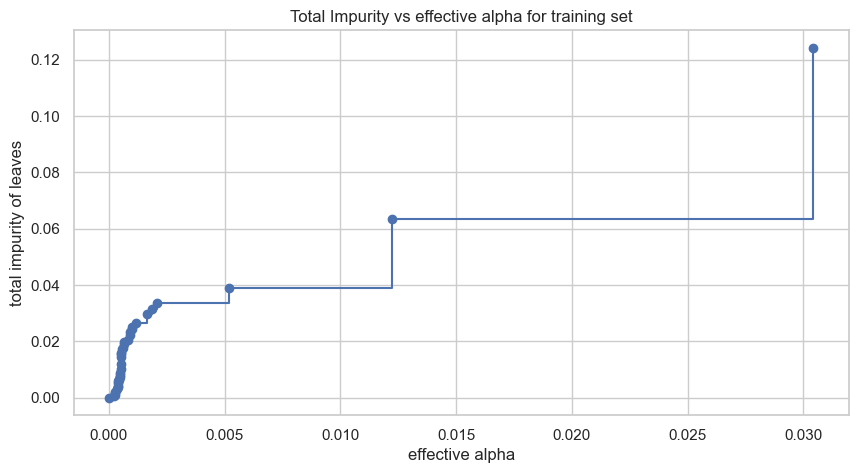

   Accuracy  Recall  Precision   F1
0  0.895333     0.0        0.0  0.0


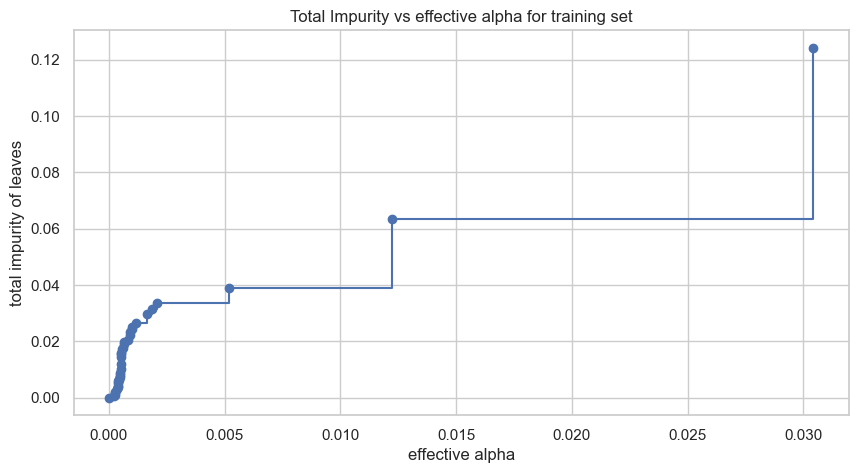

In [30]:
# -----------------------------
# 2. Post-Pruning: Cost Complexity Pruning
# -----------------------------
# Use the cost_complexity_pruning_path to obtain effective alphas.
path = dt_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities
print("Number of candidate alpha values:", len(ccp_alphas))

# Evaluate models for different ccp_alpha values.
post_models = []
post_acc = []

for ccp_alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    model.fit(X_train, y_train)
    y_pred_post = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_post)
    recall = recall_score(y_test, y_pred_post)
    precision = precision_score(y_test, y_pred_post)
    f1 = f1_score(y_test, y_pred_post)
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,}, index=[0],)
    print(df_perf)
    post_models.append(model)
    post_acc.append(acc)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
    ax.set_xlabel("effective alpha")
    ax.set_ylabel("total impurity of leaves")
    ax.set_title("Total Impurity vs effective alpha for training set")
    plt.show()

In [31]:
# Identify the best post-pruned model based on test accuracy.
best_index = np.argmax(post_acc)
best_ccp_alpha = ccp_alphas[best_index]
postpruned_model = post_models[best_index]
acc_post = post_acc[best_index]

print("Best ccp_alpha for Post-Pruning: {:.5f}".format(best_ccp_alpha))
print("Post-Pruned Model Accuracy: {:.3f}".format(acc_post))
print("Post-Pruned Model Classification Report:")
print(classification_report(y_test, postpruned_model.predict(X_test)))
print("\n")

Best ccp_alpha for Post-Pruning: 0.00000
Post-Pruned Model Accuracy: 0.987
Post-Pruned Model Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.95      0.92      0.94       157

    accuracy                           0.99      1500
   macro avg       0.97      0.96      0.96      1500
weighted avg       0.99      0.99      0.99      1500





In [32]:
# -----------------------------
# 3. Model Comparison and Final Model Selection
# -----------------------------
print("Model Performance Comparison:")
print("Baseline (Unpruned) Accuracy: {:.3f}".format(accuracy))
print("Pre-Pruned Accuracy: {:.3f}".format(acc_pre))
print("Post-Pruned Accuracy: {:.3f}".format(acc_post))
print("\n")

# Select the best model (post-pruned model)
final_model = postpruned_model

Model Performance Comparison:
Baseline (Unpruned) Accuracy: 0.984
Pre-Pruned Accuracy: 0.970
Post-Pruned Accuracy: 0.987




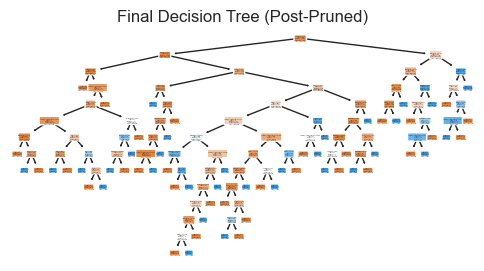

Final Decision Tree Rules:
|--- Income <= 113.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Income_to_Experience <= 22.50
|   |   |   |   |--- Family_4 <= 0.50
|   |   |   |   |   |--- Income_to_Experience <= 6.47
|   |   |   |   |   |   |--- Education_2 <= 0.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Education_2 >  0.50
|   |   |   |   |   |   |   |--- CCAvg <= 1.45
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- CCAvg >  1.45
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Income_to_Experience >  6.47
|   |   |   |   |   |   |--- Age <= 34.00
|   |   |   |   |   |   |   |--- Age <= 28.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- Age >  28.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Age >  34.00
|   |   |   |   |   |   |   |--- Age <= 36.50
|   |   |

In [33]:
# -----------------------------
# 4. Extract and Visualize Decision Rules for the Final Model
# -----------------------------
plt.figure(figsize=(6, 3))
plot_tree(final_model, feature_names=X.columns, class_names=["No Loan", "Loan"],
          filled=True, rounded=True)
plt.title("Final Decision Tree (Post-Pruned)")
plt.show()

# Print textual rules of the decision tree.
tree_rules = export_text(final_model, feature_names=list(X.columns))
print("Final Decision Tree Rules:")
print(tree_rules)

Feature Importances for the Final Model:
Income                  0.308040
Education_2             0.217427
Education_3             0.153079
Family_4                0.081827
Family_3                0.081292
CCAvg                   0.057983
Income_to_Experience    0.027611
ZIPCode                 0.018881
Age                     0.017776
Experience              0.013762
Mortgage                0.013733
CreditCard_1            0.006029
Family_2                0.002558
High_Income             0.000000
Online_1                0.000000
dtype: float64


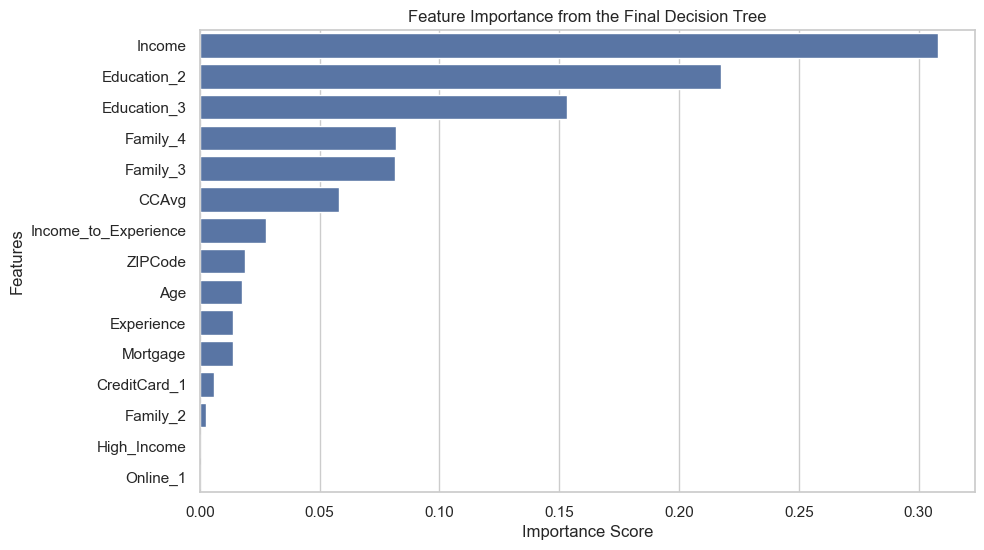

In [34]:
# -----------------------------
# 5. Feature Importance
# -----------------------------
importances = pd.Series(final_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)
print("Feature Importances for the Final Model:")
print(importances_sorted)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_sorted, y=importances_sorted.index)
plt.title("Feature Importance from the Final Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

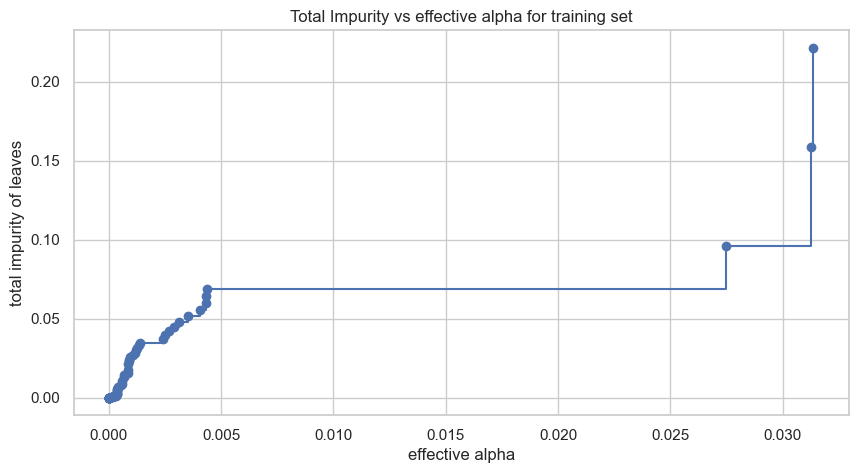

In [35]:
clf = DecisionTreeClassifier(random_state=1, class_weight={0: 0.15, 1: 0.85})
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

Number of nodes in the last tree is: 1 with ccp_alpha: 0.2424128377450154


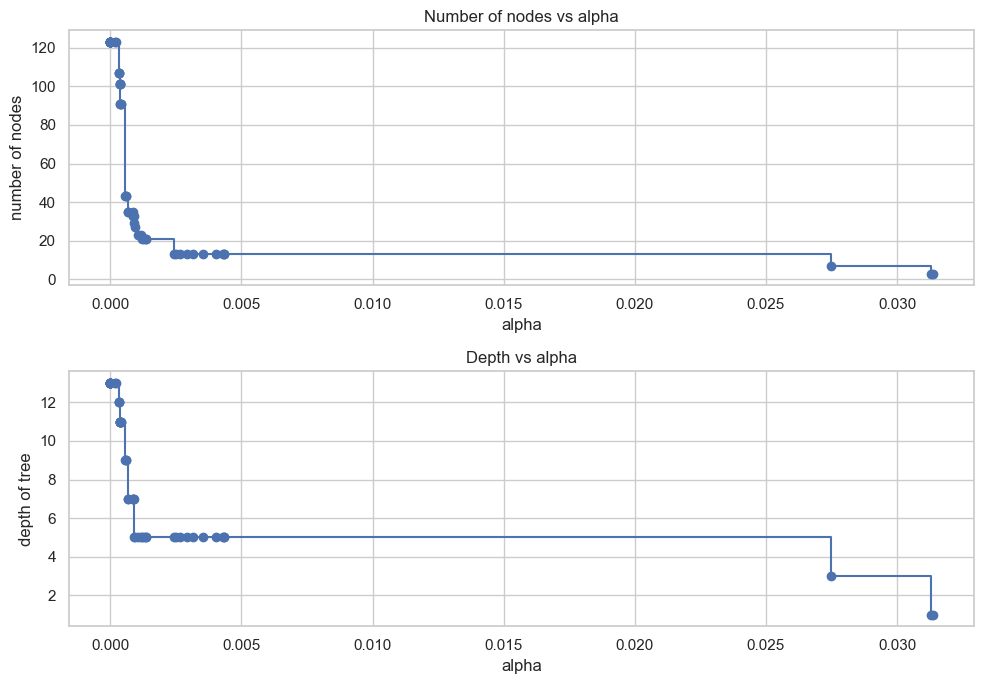

In [36]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha
    )
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

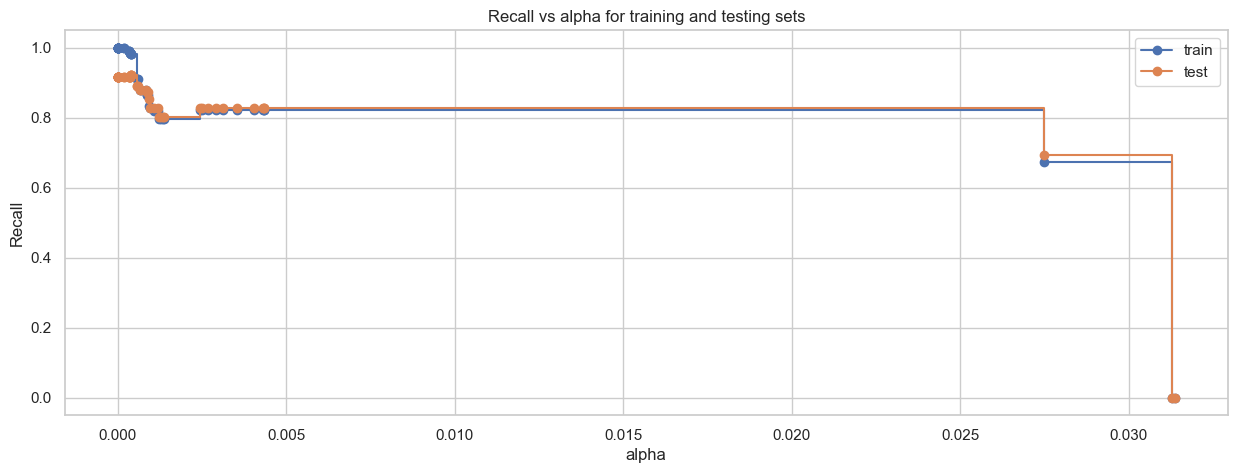

In [37]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

### Actionable Insights & Recommendations - Conclude with the key takeaways for the marketing team - What would your advice be on how to do this campaign?

### Conclusions
1. We conducted an in-depth analysis using various techniques and developed a predictive model using a Decision Tree Classifier. This model effectively identifies customers who are likely to accept personal loan offers.
2. Through visualizations such as decision trees and confusion matrices, we gained insights into the model's performance and structure. One of the primary advantages of decision trees is their simplicity and interpretability.
3. Our findings confirmed that Decision Trees require minimal data preprocessing and can still perform well even in the presence of outliers and class imbalances, showcasing their robustness and adaptability.
4. Key variables influencing personal loan acceptance include Income, Family Size, Education Level, and Credit Card Average Spending (CCAvg)—all of which play a crucial role in determining customer behavior.

### Actionable Insights & Recommendations:

1. Target Customer Segments:
   • Our Decision Tree analysis indicates that income levels and associated financial behaviors 
     (e.g., high average credit card spending and significant mortgage values) are key predictors 
     of personal loan uptake.
   • Customers with higher educational attainment (Graduate/Advanced levels) also show a greater 
     propensity toward personal loans.
   • Focus on customers who have financial profiles demonstrating high income and robust credit 
     behaviors, as they are more likely to be receptive to personal loan offers.

2. Campaign Strategy:
   • Tailor your marketing messages to emphasize the benefits of personal loans for individuals 
     seeking financial flexibility and to support larger investments or debt consolidation.
   • Use multi-channel marketing (digital media, email campaigns, and targeted ads) to reach the 
     high-value customer segments identified by our model.
   • Leverage personalized messaging that resonates with customers’ financial strengths and goals. 

3. Product Positioning & Continuous Improvement:
   • Highlight exclusive offers or competitive interest rates on personal loans in your campaign 
     messaging to attract financially robust customers.
   • Regularly update and refine the predictive model with new customer data to continuously improve 
     customer segmentation and outreach strategies.
   • Monitor campaign effectiveness through key metrics (e.g., conversion rates, ROI) and adjust 
     the campaign focus based on customer feedback and evolving data insights.

### Final Recommendation 
Focus on a targeted campaign that prioritizes high-income, highly educated, and financially active customers. Emphasize the value of personal loans as tools for financial empowerment, and maintain continuous monitoring to further optimize engagement and conversion rates.